# CIFAR-100 Classification

In [1]:
# 1. Setup
import os, sys

REPO_URL = "https://github.com/NatanSisoev/CIFAR-100-Classification.git"
REPO_DIR = "/content/CIFAR-100-Classification"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

!pip install -q loguru

Cloning into '/content/CIFAR-100-Classification'...
remote: Enumerating objects: 250, done.
remote: Counting objects: 100% (250/250), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 250 (delta 131), reused 202 (delta 85), pack-reused 0 (from 0)
Receiving objects: 100% (250/250), 1.65 MiB | 7.45 MiB/s, done.
Resolving deltas: 100% (131/131), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.4 MB/s eta 0:00:00


In [2]:
# 2. Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# 3. Imports
from configs import REMOTE_BASE_DIR, NUM_EPOCHS
from data import get_cifar100_loaders
from models import SmallResNet, get_device, plot_history, train
from loguru import logger

In [4]:
# 4. Device & data
device = get_device()
train_loader, test_loader = get_cifar100_loaders()

2026-04-03 18:05:41.963 | WARNING  | models.utils:get_device:48 - using device: cpu
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 169M/169M [00:05<00:00, 28.9MB/s] 
2026-04-03 18:05:52.555 | SUCCESS  | data.datasets:get_cifar100_loaders:19 - Succesfully loaded train loader.
2026-04-03 18:05:52.558 | SUCCESS  | data.datasets:get_cifar100_loaders:20 - Succesfully loaded test loader.


In [5]:
# 5. Init model
BEST_SAVE_PATH = REMOTE_BASE_DIR + "smallresnet_best.pth"
LAST_SAVE_PATH = REMOTE_BASE_DIR + "smallresnet_last.pth"

# model, criterion, optimizer, scheduler = SmallResNet.init(device)
state = SmallResNet.restore(device, save_path=LAST_SAVE_PATH)

2026-04-03 18:05:55.152 | INFO     | models.smallresnet:restore:172 - Restored SmallResNet from '/content/drive/MyDrive/XNAP/smallresnet_last.pth' (epoch 79, best acc 43.39%)


In [7]:
# 6. Train
# Fresh start:
"""model, history = train(
    device=device,
    model=model,
    dataloader_train=train_loader,
    dataloader_test=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    best_save_path=BEST_SAVE_PATH,
    last_save_path=LAST_SAVE_PATH,
)"""

# Resume (uncomment and replace the block above:
model, history = train(
    device=device,
    dataloader_train=train_loader,
    dataloader_test=test_loader,
    num_epochs=200,
    best_save_path=BEST_SAVE_PATH,
    last_save_path=LAST_SAVE_PATH,
    **state,
)

2026-04-03 18:07:08.830 | INFO     | models.train:train:32 - Training resumed — 105,900 parameters


KeyboardInterrupt: 

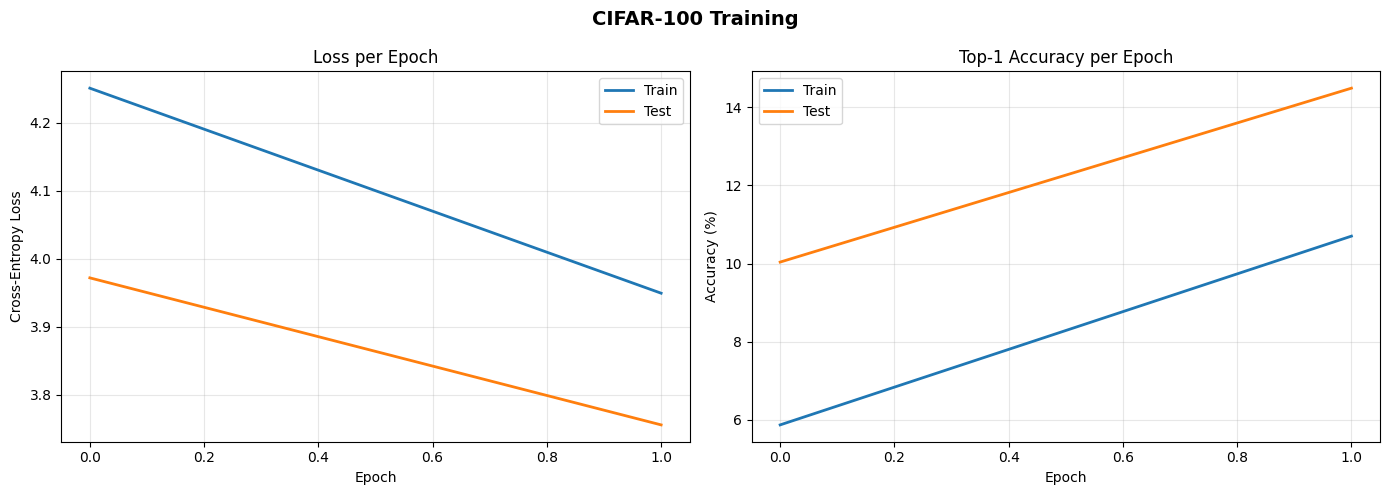

2026-04-01 20:35:38.896 | INFO     | models.utils:plot_history:40 - Training plot saved to '/content/drive/MyDrive/XNAP/history.png'


In [ ]:
# 7. Results
plot_history(history, save_path=REMOTE_BASE_DIR + "smallresnet_history.png")